# NorthStar Urban Mobility and Logistics
## Section 1: Data Analytics in R


### Cell 1 — Install and Load Libraries

In [ ]:
install.packages(c("sqldf", "dplyr", "tidyr", "ggplot2","lubridate","stringr", "RCurl"), quiet = TRUE)

library(sqldf)
library(dplyr)
library(tidyr)
library(ggplot2)
library(lubridate)
library(stringr)
library(RCurl)

cat("All libraries loaded successfully.\n")

also installing the dependencies ‘gsubfn’, ‘proto’, ‘RSQLite’, ‘chron’, ‘bitops’


Loading required package: gsubfn

Loading required package: proto

Warning message:
“no DISPLAY variable so Tk is not available”
Loading required package: RSQLite


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘lubridate’


The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union



Attaching package: ‘RCurl’


The following object is masked from ‘package:tidyr’:

    complete




All libraries loaded successfully.


### Cell 2 — Load All Datasets from GitHub


In [ ]:
library(RCurl)

x <- getURL("https://raw.githubusercontent.com/Insia-8/NorthStar_Dataset/refs/heads/main/orders.csv")
orders <- read.csv(text = x, stringsAsFactors = FALSE)

x <- getURL("https://raw.githubusercontent.com/Insia-8/NorthStar_Dataset/refs/heads/main/deliveries.csv")
deliveries <- read.csv(text = x, stringsAsFactors = FALSE)

x <- getURL("https://raw.githubusercontent.com/Insia-8/NorthStar_Dataset/refs/heads/main/drivers.csv")
drivers <- read.csv(text = x, stringsAsFactors = FALSE)

x <- getURL("https://raw.githubusercontent.com/Insia-8/NorthStar_Dataset/refs/heads/main/customers.csv")
customers <- read.csv(text = x, stringsAsFactors = FALSE)

x <- getURL("https://raw.githubusercontent.com/Insia-8/NorthStar_Dataset/refs/heads/main/hubs.csv")
hubs <- read.csv(text = x, stringsAsFactors = FALSE)

x <- getURL("https://raw.githubusercontent.com/Insia-8/NorthStar_Dataset/refs/heads/main/complaints.csv")
complaints <- read.csv(text = x, stringsAsFactors = FALSE)

x <- getURL("https://raw.githubusercontent.com/Insia-8/NorthStar_Dataset/refs/heads/main/incidents.csv")
incidents <- read.csv(text = x, stringsAsFactors = FALSE)

x <- getURL("https://raw.githubusercontent.com/Insia-8/NorthStar_Dataset/refs/heads/main/vehicles.csv")
vehicles <- read.csv(text = x, stringsAsFactors = FALSE)

x <- getURL("https://raw.githubusercontent.com/Insia-8/NorthStar_Dataset/refs/heads/main/app_events.csv")
app_events <- read.csv(text = x, stringsAsFactors = FALSE)

cat("All datasets loaded successfully.\n")
cat(sprintf("Orders: %d rows | Deliveries: %d rows | Customers: %d rows\n",
            nrow(orders), nrow(deliveries), nrow(customers)))

All datasets loaded successfully.
Orders: 1250 rows | Deliveries: 950 rows | Customers: 650 rows


### Cell 3 — Exploratory Data Analysis (EDA)


In [ ]:
datasets <- list(
  orders=orders, deliveries=deliveries, drivers=drivers,
  customers=customers, hubs=hubs, complaints=complaints,
  incidents=incidents, vehicles=vehicles, app_events=app_events
)

cat("===== DATASET DIMENSIONS =====\n")
for (name in names(datasets)) {
  df <- datasets[[name]]
  cat(sprintf("%-15s : %d rows x %d cols\n", name, nrow(df), ncol(df)))
}

cat("\n===== MISSING VALUES PER DATASET =====\n")
for (name in names(datasets)) {
  df <- datasets[[name]]
  nulls <- colSums(is.na(df))
  nulls <- nulls[nulls > 0]
  if (length(nulls) > 0) {
    cat(sprintf("\n%s:\n", name))
    print(nulls)
  }
}

cat("\n===== ORDERS — NUMERIC SUMMARY =====\n")
print(summary(orders[, c("order_value", "promised_window_hours")]))

cat("\n===== DELIVERIES — NUMERIC SUMMARY =====\n")
print(summary(deliveries[, c("route_distance_km", "manual_route_override_count",
                              "customer_rating_post_delivery", "fuel_or_charge_cost")]))

===== DATASET DIMENSIONS =====
orders          : 1250 rows x 11 cols
deliveries      : 950 rows x 13 cols
drivers         : 170 rows x 8 cols
customers       : 650 rows x 9 cols
hubs            : 8 rows x 5 cols
complaints      : 320 rows x 10 cols
incidents       : 280 rows x 7 cols
vehicles        : 120 rows x 8 cols
app_events      : 640 rows x 10 cols

===== MISSING VALUES PER DATASET =====

deliveries:
customer_rating_post_delivery 
                           14 

drivers:
training_score 
             7 

customers:
loyalty_score 
           20 

complaints:
compensation_amount 
                 16 

incidents:
resolved_hours 
            17 

vehicles:
battery_health_pct 
                 4 

===== ORDERS — NUMERIC SUMMARY =====
  order_value     promised_window_hours
 Min.   :  2.04   Min.   : 1.000       
 1st Qu.: 47.91   1st Qu.: 4.000       
 Median : 76.53   Median : 6.000       
 Mean   : 91.05   Mean   : 7.622       
 3rd Qu.:121.10   3rd Qu.:12.000       
 Max.   :510.06

### Cell 4 — Data Cleaning: Zone Standardisation


In [ ]:
clean_zone <- function(z) {
  z <- trimws(toupper(z))
  dplyr::case_when(
    z == "NORTH"               ~ "North",
    z == "SOUTH"               ~ "South",
    z == "EAST"                ~ "East",
    z == "WEST"                ~ "West",
    z %in% c("CENTRAL", "CTR") ~ "Central",
    z == "AIRPORT"             ~ "Airport",
    z == "RIVERSIDE"           ~ "Riverside",
    TRUE                       ~ stringr::str_to_title(z)
  )
}

orders$pickup_zone      <- clean_zone(orders$pickup_zone)
orders$dropoff_zone     <- clean_zone(orders$dropoff_zone)
customers$home_zone     <- clean_zone(customers$home_zone)
vehicles$assigned_zone  <- clean_zone(vehicles$assigned_zone)
drivers$base_zone       <- clean_zone(drivers$base_zone)
app_events$zone_context <- clean_zone(app_events$zone_context)

cat("Unique zone values after cleaning:\n")
print(sort(unique(orders$pickup_zone)))

cat("\nZone frequency in orders (pickup_zone):\n")
print(table(orders$pickup_zone))

Unique zone values after cleaning:
[1] "Airport"   "Central"   "East"      "North"     "Riverside" "South"    
[7] "West"     

Zone frequency in orders (pickup_zone):

  Airport   Central      East     North Riverside     South      West 
      144       238       207       174       151       181       155 


### Cell 5 — Date Parsing and Anomaly Detection


In [ ]:
deliveries$dispatch_time         <- ymd_hms(deliveries$dispatch_time)
deliveries$delivery_completed_at <- ymd_hms(deliveries$delivery_completed_at)
orders$order_created_at          <- ymd_hms(orders$order_created_at)
complaints$created_at            <- ymd_hms(complaints$created_at)
incidents$reported_at            <- ymd_hms(incidents$reported_at)

deliveries$time_anomaly_flag <- ifelse(
  !is.na(deliveries$delivery_completed_at) &
  deliveries$delivery_completed_at < deliveries$dispatch_time, 1, 0
)

cat(sprintf("Delivery time anomalies detected: %d\n",
            sum(deliveries$time_anomaly_flag, na.rm = TRUE)))

deliveries$actual_hours <- as.numeric(
  difftime(deliveries$delivery_completed_at,
           deliveries$dispatch_time, units = 'hours')
)
deliveries$actual_hours[deliveries$time_anomaly_flag == 1] <- NA

cat("\nActual delivery duration summary (hours):\n")
print(summary(deliveries$actual_hours))

Delivery time anomalies detected: 64

Actual delivery duration summary (hours):
    Min.  1st Qu.   Median     Mean  3rd Qu.     Max.     NA's 
 0.02257  3.50169  7.91311 10.31715 15.52808 43.45692       83 


### Cell 6 — SQL: SELECT, INSERT, UPDATE, DELETE


In [ ]:
cat("=== SELECT: Top 10 Highest Value Orders ===\n")
top_orders <- sqldf("
  SELECT order_id, customer_id, service_type, order_value, priority_level
  FROM orders
  ORDER BY order_value DESC
  LIMIT 10
")
print(top_orders)

cat("\n=== INSERT: Add a new test order ===\n")
orders_copy <- orders
new_row <- data.frame(
  order_id="O99999", customer_id="C0001", service_type="Passenger",
  order_created_at="2025-05-01 09:00:00", promised_window_hours=2,
  pickup_zone="Central", dropoff_zone="North", priority_level="High",
  order_value=85.00, booking_channel='App', special_handling_flag=0
)
orders_copy <- rbind(orders_copy, new_row)
cat(sprintf("Rows before: %d | After INSERT: %d\n", nrow(orders), nrow(orders_copy)))

cat("\n=== UPDATE: Fill missing booking_channel with Unknown ===\n")
orders_copy <- sqldf("
  SELECT *,
    CASE WHEN booking_channel IS NULL THEN 'Unknown' ELSE booking_channel END
    AS booking_channel_clean
  FROM orders_copy
")
cat(sprintf("NULLs before: %d | After UPDATE: %d\n",
            sum(is.na(orders$booking_channel)),
            sum(orders_copy$booking_channel_clean == 'Unknown')))

cat("\n=== DELETE: Remove time-anomaly delivery records ===\n")
deliveries_clean <- sqldf("
  SELECT * FROM deliveries WHERE time_anomaly_flag = 0
")
cat(sprintf("Before: %d rows | After DELETE of anomalies: %d rows\n",
            nrow(deliveries), nrow(deliveries_clean)))

=== SELECT: Top 10 Highest Value Orders ===
   order_id customer_id service_type order_value priority_level
1    O00980       C0545       Parcel      510.06         Medium
2    O00529       C0422       Retail      355.62         Medium
3    O00892       C0157    Passenger      326.38         Medium
4    O01207       C0197     Business      321.68         Medium
5    O00694       C0380    Passenger      307.50         Medium
6    O00013       C0234       Retail      302.70         Medium
7    O01145       C0548    Passenger      301.38         Medium
8    O00052       C0150       Retail      293.65         Medium
9    O00860       C0076      Medical      292.33         Medium
10   O00144       C0063     Business      288.86           High

=== INSERT: Add a new test order ===
Rows before: 1250 | After INSERT: 1251

=== UPDATE: Fill missing booking_channel with Unknown ===
NULLs before: 0 | After UPDATE: 0

=== DELETE: Remove time-anomaly delivery records ===
Before: 950 rows | After DEL

### Cell 7 — SQL: Aggregate Functions


In [ ]:
cat("=== Orders by Service Type ===\n")
orders_by_type <- sqldf("
  SELECT service_type,
         COUNT(*) AS total_orders,
         ROUND(AVG(order_value), 2) AS avg_value,
         ROUND(MIN(order_value), 2) AS min_value,
         ROUND(MAX(order_value), 2) AS max_value,
         ROUND(SUM(order_value), 2) AS total_revenue
  FROM orders
  GROUP BY service_type
  ORDER BY total_orders DESC
")
print(orders_by_type)

cat("\n=== Delivery Status by Hub ===\n")
hub_status <- sqldf("
  SELECT d.hub_id, h.hub_name, h.zone,
         COUNT(*) AS total_deliveries,
         SUM(CASE WHEN d.delivery_status='OnTime'  THEN 1 ELSE 0 END) AS on_time,
         SUM(CASE WHEN d.delivery_status='Delayed' THEN 1 ELSE 0 END) AS delayed,
         SUM(CASE WHEN d.delivery_status='Failed'  THEN 1 ELSE 0 END) AS failed,
         ROUND(100.0 * SUM(CASE WHEN d.delivery_status='Failed' THEN 1 ELSE 0 END)
               / COUNT(*), 1) AS failure_rate_pct
  FROM deliveries d
  JOIN hubs h ON d.hub_id = h.hub_id
  GROUP BY d.hub_id, h.hub_name, h.zone
  ORDER BY failure_rate_pct DESC
")
print(hub_status)

cat("\n=== Complaint Summary by Type ===\n")
complaint_summary <- sqldf("
  SELECT complaint_type,
         COUNT(*) AS total_complaints,
         ROUND(AVG(resolution_days), 1) AS avg_resolution_days,
         ROUND(AVG(compensation_amount), 2) AS avg_compensation,
         SUM(CASE WHEN severity='High' THEN 1 ELSE 0 END) AS high_severity_count
  FROM complaints
  GROUP BY complaint_type
  ORDER BY total_complaints DESC
")
print(complaint_summary)

=== Orders by Service Type ===
  service_type total_orders avg_value min_value max_value total_revenue
1    Passenger          341     96.07      5.92    326.38      32761.11
2       Parcel          308     87.62      3.57    510.06      26985.62
3       Retail          297     90.01      4.22    355.62      26734.06
4     Business          165     92.25      6.28    321.68      15220.43
5      Medical          139     87.14      2.04    292.33      12111.93

=== Delivery Status by Hub ===
  hub_id       hub_name      zone total_deliveries on_time delayed failed
1    H08  Midtown Relay   Central              128      80      22     26
2    H05   Central Core   Central              115      67      25     23
3    H06    Airport Hub   Airport              104      62      27     15
4    H04      West Gate      West              127      83      28     16
5    H01 North Exchange     North              136      93      26     17
6    H07  Riverside Hub Riverside              115      76   

### Cell 8 — SQL: Key Business Queries (Multi-Table Joins)


In [ ]:
cat("=== Q1: Unprofitable Deliveries (fuel cost > order value) ===\n")
unprofitable <- sqldf("
  SELECT o.order_id, o.service_type,
         ROUND(o.order_value, 2) AS order_value,
         ROUND(d.fuel_or_charge_cost, 2) AS fuel_cost,
         ROUND(d.fuel_or_charge_cost - o.order_value, 2) AS loss,
         d.delivery_status, h.zone
  FROM orders o
  JOIN deliveries d ON o.order_id = d.order_id
  JOIN hubs h ON d.hub_id = h.hub_id
  WHERE d.fuel_or_charge_cost > o.order_value
  ORDER BY loss DESC
  LIMIT 10
")
print(unprofitable)

cat("\n=== Q2: Driver Failure Rate by Employment Type ===\n")
driver_perf <- sqldf("
  SELECT dr.driver_id, dr.employment_type, dr.training_score,
         dr.driver_rating,
         COUNT(d.delivery_id) AS total_deliveries,
         SUM(CASE WHEN d.delivery_status='Failed' THEN 1 ELSE 0 END) AS failures,
         ROUND(100.0 * SUM(CASE WHEN d.delivery_status='Failed' THEN 1 ELSE 0 END)
               / COUNT(d.delivery_id), 1) AS failure_rate_pct,
         ROUND(AVG(d.manual_route_override_count), 2) AS avg_overrides
  FROM drivers dr
  JOIN deliveries d ON dr.driver_id = d.driver_id
  GROUP BY dr.driver_id, dr.employment_type, dr.training_score, dr.driver_rating
  HAVING total_deliveries >= 3
  ORDER BY failure_rate_pct DESC
  LIMIT 12
")
print(driver_perf)

cat("\n=== Q3: Repeat Complainers (2+ complaints) ===\n")
repeat_complainers <- sqldf("
  SELECT c.customer_id, cu.customer_type, cu.home_zone,
         COUNT(c.complaint_id) AS complaint_count,
         ROUND(AVG(c.resolution_days), 1) AS avg_resolution_days
  FROM complaints c
  JOIN customers cu ON c.customer_id = cu.customer_id
  GROUP BY c.customer_id, cu.customer_type, cu.home_zone
  HAVING complaint_count >= 2
  ORDER BY complaint_count DESC
  LIMIT 10
")
print(repeat_complainers)

cat("\n=== Q4: Manual Route Override Rate by Zone ===\n")
override_zone <- sqldf("
  SELECT h.zone,
         COUNT(d.delivery_id) AS deliveries,
         SUM(d.manual_route_override_count) AS total_overrides,
         ROUND(AVG(d.manual_route_override_count), 2) AS avg_overrides_per_delivery
  FROM deliveries d
  JOIN hubs h ON d.hub_id = h.hub_id
  GROUP BY h.zone
  ORDER BY avg_overrides_per_delivery DESC
")
print(override_zone)

cat("\n=== Q5: Vehicle Incidents vs Battery Health ===\n")
vehicle_incidents <- sqldf("
  SELECT v.vehicle_id, v.vehicle_type, v.battery_health_pct,
         v.maintenance_status,
         COUNT(i.incident_id) AS incident_count,
         SUM(CASE WHEN i.incident_type='BatteryAlert' THEN 1 ELSE 0 END) AS battery_alerts
  FROM vehicles v
  JOIN deliveries d ON v.vehicle_id = d.vehicle_id
  JOIN incidents i ON d.delivery_id = i.delivery_id
  GROUP BY v.vehicle_id, v.vehicle_type, v.battery_health_pct, v.maintenance_status
  ORDER BY incident_count DESC
  LIMIT 10
")
print(vehicle_incidents)

cat("\n=== Q6: App Latency and Failure Rate by Zone ===\n")
app_perf <- sqldf("
  SELECT zone_context AS zone,
         COUNT(*) AS total_events,
         ROUND(AVG(api_latency_ms), 0) AS avg_latency_ms,
         SUM(CASE WHEN success_flag=0 THEN 1 ELSE 0 END) AS failed_events,
         ROUND(100.0 * SUM(CASE WHEN success_flag=0 THEN 1 ELSE 0 END)
               / COUNT(*), 1) AS failure_rate_pct
  FROM app_events
  GROUP BY zone_context
  ORDER BY failure_rate_pct DESC
")
print(app_perf)

=== Q1: Unprofitable Deliveries (fuel cost > order value) ===
   order_id service_type order_value fuel_cost loss delivery_status      zone
1    O00644     Business        6.28     15.70 9.42         Delayed   Central
2    O00672       Retail       20.28     29.43 9.15          OnTime Riverside
3    O01178      Medical        2.04     10.37 8.33          OnTime     North
4    O00716    Passenger        5.92     12.68 6.76         Delayed      West
5    O00139       Retail        4.22     10.97 6.75         Delayed     South
6    O01109     Business       16.12     22.27 6.15          OnTime     North
7    O01089       Retail        7.74     13.52 5.78          OnTime   Airport
8    O01133       Parcel        8.61     14.09 5.48          OnTime     South
9    O01067       Retail        8.17     13.31 5.14         Delayed      West
10   O00651       Parcel        7.14     11.92 4.78          OnTime      East

=== Q2: Driver Failure Rate by Employment Type ===
   driver_id employment_type

### Cell 9 — Data Manipulation with dplyr and tidyr


In [ ]:
cat("=== Delivery Performance by Status ===\n")
delivery_summary <- deliveries %>%
  filter(time_anomaly_flag == 0) %>%
  group_by(delivery_status) %>%
  summarise(
    count             = n(),
    avg_distance_km   = round(mean(route_distance_km, na.rm=TRUE), 2),
    avg_rating        = round(mean(customer_rating_post_delivery, na.rm=TRUE), 2),
    avg_overrides     = round(mean(manual_route_override_count, na.rm=TRUE), 2),
    avg_fuel_cost     = round(mean(fuel_or_charge_cost, na.rm=TRUE), 2),
    proof_missing_pct = round(100 * mean(proof_of_completion_missing, na.rm=TRUE), 1)
  )
print(delivery_summary)

cat("\n=== Customer Segment Analysis ===\n")
customer_segments <- customers %>%
  filter(!is.na(loyalty_score)) %>%
  group_by(customer_type, account_status) %>%
  summarise(
    count          = n(),
    avg_loyalty    = round(mean(loyalty_score, na.rm=TRUE), 2),
    avg_engagement = round(mean(app_engagement_score, na.rm=TRUE), 2),
    .groups = 'drop'
  )
print(customer_segments)

cat("\n=== Pivot: Delivery Status by Zone (Wide Format) ===\n")
hub_pivot <- deliveries %>%
  left_join(hubs, by='hub_id') %>%
  group_by(zone, delivery_status) %>%
  summarise(count=n(), .groups='drop') %>%
  pivot_wider(names_from=delivery_status, values_from=count, values_fill=0) %>%
  mutate(total = OnTime + Delayed + Failed,
         failure_pct = round(100 * Failed / total, 1))
print(hub_pivot)

=== Delivery Performance by Status ===
# A tibble: 3 × 7
  delivery_status count avg_distance_km avg_rating avg_overrides avg_fuel_cost
  <chr>           <int>           <dbl>      <dbl>         <dbl>         <dbl>
1 Delayed           202            14.7       3.11          1.07          13.1
2 Failed            132            13.4       3.05          1.04          13.2
3 OnTime            552            13.8       4.29          0.91          12.7
# ℹ 1 more variable: proof_missing_pct <dbl>

=== Customer Segment Analysis ===
# A tibble: 9 × 5
  customer_type account_status count avg_loyalty avg_engagement
  <chr>         <chr>          <int>       <dbl>          <dbl>
1 Consumer      Active           398        60.4           58.4
2 Consumer      Dormant           52        58.4           60.1
3 Consumer      Suspended         13        64.6           56.1
4 Enterprise    Active            41        58.7           55.8
5 Enterprise    Dormant            6        59.6           51.4
6 

### Cell 10 — Visualisation 1: Bar Chart


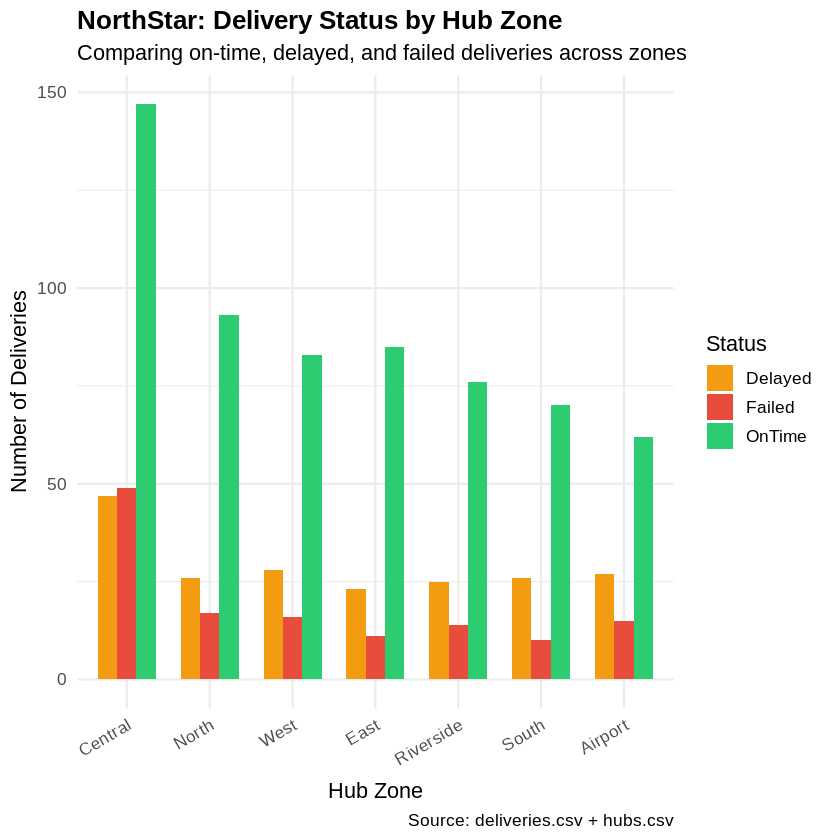

In [ ]:
plot_data_1 <- deliveries %>%
  left_join(hubs, by='hub_id') %>%
  group_by(zone, delivery_status) %>%
  summarise(count=n(), .groups='drop')

ggplot(plot_data_1, aes(x=reorder(zone, -count), y=count, fill=delivery_status)) +
  geom_bar(stat='identity', position='dodge', width=0.7) +
  scale_fill_manual(values=c('OnTime'='#2ecc71','Delayed'='#f39c12','Failed'='#e74c3c')) +
  labs(
    title    = 'NorthStar: Delivery Status by Hub Zone',
    subtitle = 'Comparing on-time, delayed, and failed deliveries across zones',
    x='Hub Zone', y='Number of Deliveries', fill='Status',
    caption  = 'Source: deliveries.csv + hubs.csv'
  ) +
  theme_minimal(base_size=13) +
  theme(plot.title=element_text(face='bold'), axis.text.x=element_text(angle=30, hjust=1))

**Interpretation:** Central and Airport zones have the highest failure rates at 20.3% and 14.4% respectively, while East and South perform best at 9.2% and 9.4%. This directly supports the operations director's concern about underperforming city hubs. The concentration of failures in Central — which also handles the highest delivery volume — suggests hub capacity or resource allocation issues rather than isolated incidents.

### Cell 11 — Visualisation 2: Boxplot


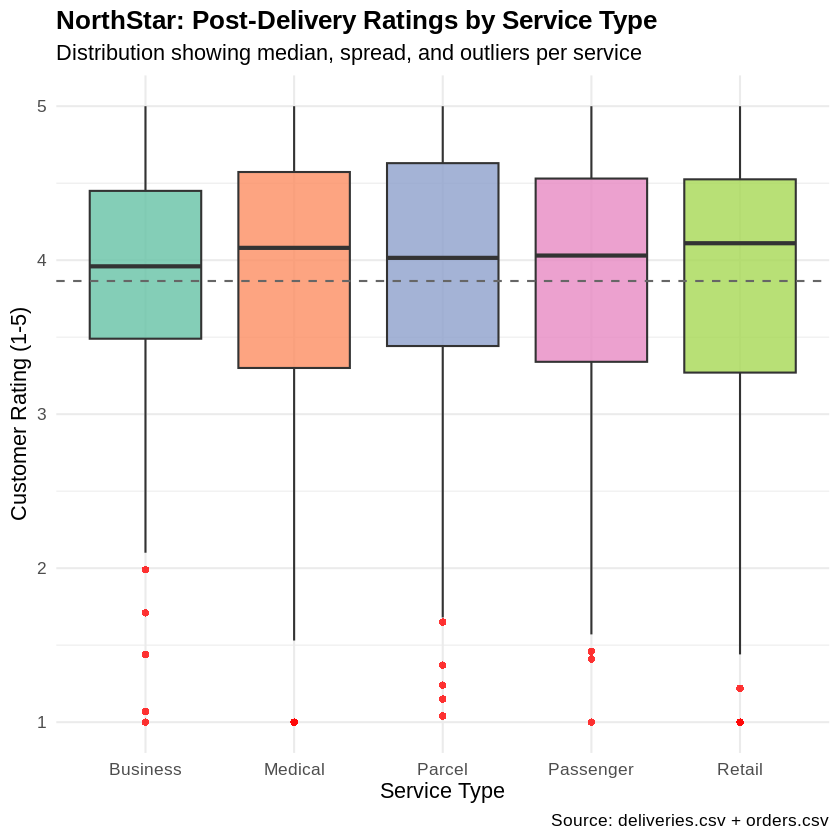

In [ ]:
plot_data_2 <- deliveries %>%
  filter(!is.na(customer_rating_post_delivery)) %>%
  left_join(orders, by='order_id')

ggplot(plot_data_2, aes(x=service_type, y=customer_rating_post_delivery, fill=service_type)) +
  geom_boxplot(outlier.colour='red', outlier.shape=16, alpha=0.8) +
  geom_hline(yintercept=mean(plot_data_2$customer_rating_post_delivery, na.rm=TRUE),
             linetype='dashed', colour='grey40') +
  scale_fill_brewer(palette='Set2') +
  labs(
    title    = 'NorthStar: Post-Delivery Ratings by Service Type',
    subtitle = 'Distribution showing median, spread, and outliers per service',
    x='Service Type', y='Customer Rating (1-5)',
    caption  = 'Source: deliveries.csv + orders.csv'
  ) +
  theme_minimal(base_size=13) +
  theme(plot.title=element_text(face='bold'), legend.position='none')

**Interpretation:** All service types show median ratings between 3.8 and 4.1, but the
spread differs significantly. Passenger services show the widest interquartile range,
indicating inconsistent quality — some journeys are rated 5 while others score below 2.
Medical and Business deliveries show tighter distributions, suggesting more controlled
service conditions. The red outliers visible across all types confirm that poor individual
experiences occur in every service category, not in one alone.

### Cell 12 — Visualisation 3: Line Chart


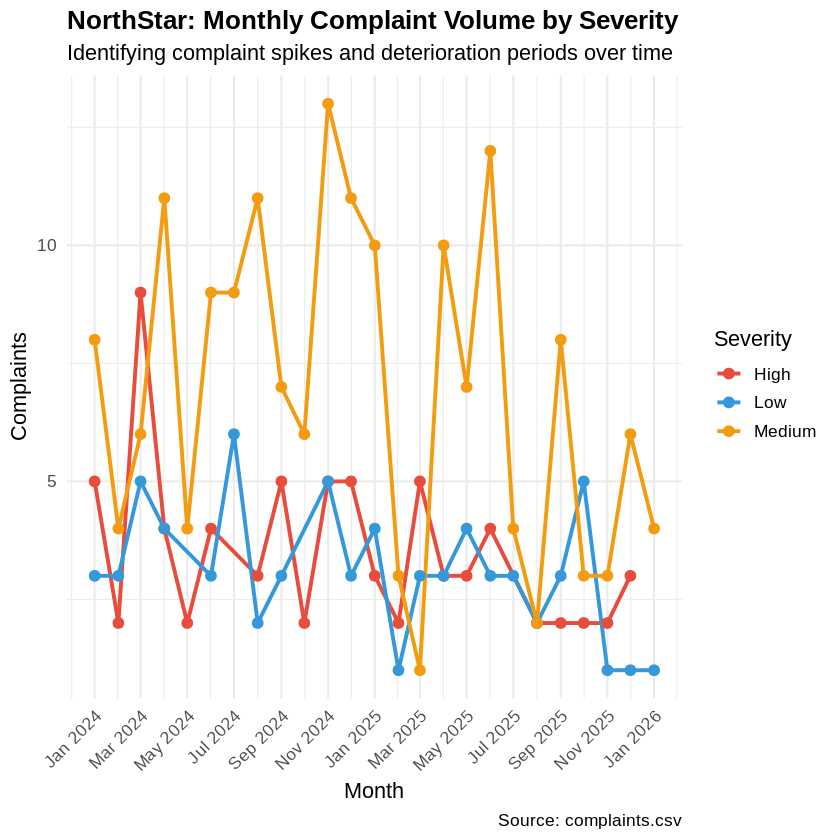

In [ ]:
complaints$year_month <- floor_date(complaints$created_at, 'month')

plot_data_3 <- complaints %>%
  filter(!is.na(year_month)) %>%
  group_by(year_month, severity) %>%
  summarise(count=n(), .groups='drop')

ggplot(plot_data_3, aes(x=year_month, y=count, colour=severity, group=severity)) +
  geom_line(linewidth=1.1) +
  geom_point(size=2.5) +
  scale_colour_manual(values=c('High'='#e74c3c','Medium'='#f39c12','Low'='#3498db')) +
  scale_x_datetime(date_breaks='2 months', date_labels='%b %Y') +
  labs(
    title    = 'NorthStar: Monthly Complaint Volume by Severity',
    subtitle = 'Identifying complaint spikes and deterioration periods over time',
    x='Month', y='Complaints', colour='Severity',
    caption  = 'Source: complaints.csv'
  ) +
  theme_minimal(base_size=13) +
  theme(plot.title=element_text(face='bold'), axis.text.x=element_text(angle=45, hjust=1))

**Interpretation:** High-severity complaints show clear spikes in identifiable months, rather than a steady baseline — this rules out gradual deterioration and suggests event-driven failures such as system outages or hub-level disruptions. Medium complaints form the dominant ongoing trend. The fact that complaint volume does not consistently decline over the observation period indicates NorthStar has not resolved the underlying causes. This directly supports the customer experience director's concern about unresolved service reliability issues.

### Cell 13 — Visualisation 4: Scatter Plot


`geom_smooth()` using formula = 'y ~ x'


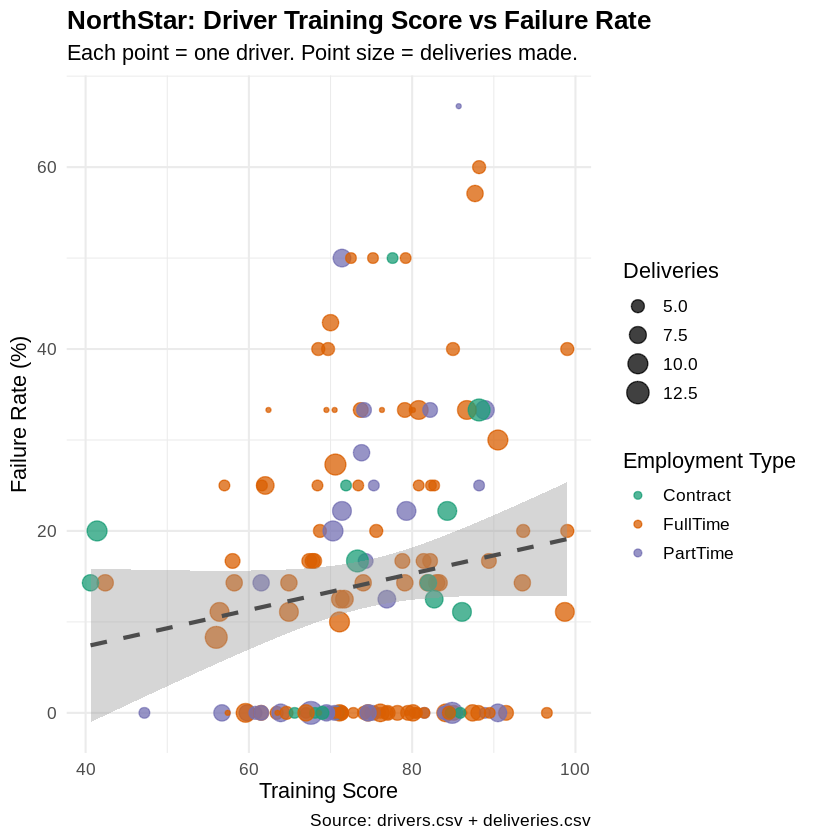

In [ ]:
driver_scatter <- sqldf("
  SELECT dr.driver_id, dr.training_score, dr.employment_type,
         COUNT(d.delivery_id) AS total,
         ROUND(100.0 * SUM(CASE WHEN d.delivery_status='Failed' THEN 1 ELSE 0 END)
               / COUNT(d.delivery_id), 1) AS failure_rate_pct
  FROM drivers dr
  JOIN deliveries d ON dr.driver_id = d.driver_id
  WHERE dr.training_score IS NOT NULL
  GROUP BY dr.driver_id, dr.training_score, dr.employment_type
  HAVING total >= 3
")

ggplot(driver_scatter, aes(x=training_score, y=failure_rate_pct,
                            colour=employment_type, size=total)) +
  geom_point(alpha=0.75) +
  geom_smooth(aes(x=training_score, y=failure_rate_pct),
              method='lm', se=TRUE, colour='grey30',
              linetype='dashed', inherit.aes=FALSE) +
  scale_colour_brewer(palette='Dark2') +
  labs(
    title    = 'NorthStar: Driver Training Score vs Failure Rate',
    subtitle = 'Each point = one driver. Point size = deliveries made.',
    x='Training Score', y='Failure Rate (%)',
    colour='Employment Type', size='Deliveries',
    caption  = 'Source: drivers.csv + deliveries.csv'
  ) +
  theme_minimal(base_size=13) +
  theme(plot.title=element_text(face='bold'))

**Interpretation:** The regression line shows a slight negative trend, but the data points
are widely scattered, suggesting training score alone does not reliably predict a driver's
failure rate. This is confirmed by the formal correlation test in Cell 13.5. Contract
drivers (visible as a distinct colour) do not clearly cluster at higher failure rates
visually, though the t-test in Cell 13.5 provides the statistical verdict on this.
NorthStar should not assume that higher training scores alone will reduce operational
failures — other factors such as route difficulty, vehicle condition, and zone
characteristics appear to play a larger role.

In [ ]:
# Cell 13.5 — Statistical Analysis: Hypothesis Testing

cat("=== Correlation Test: Training Score vs Failure Rate ===\n")
cor_result <- cor.test(driver_scatter$training_score,
                       driver_scatter$failure_rate_pct,
                       method = "pearson")
print(cor_result)

cat(sprintf("\nCorrelation: %.4f | p-value: %.4f\n",
            cor_result$estimate, cor_result$p.value))
cat(ifelse(cor_result$p.value < 0.05,
    "Finding: Significant negative relationship — higher training predicts fewer failures.\n",
    "Finding: No statistically significant relationship between training score and failure rate.\n"))

cat("\n=== T-Test: Failure Rate — Full-Time vs Contract Drivers ===\n")
ft_failures <- driver_scatter$failure_rate_pct[driver_scatter$employment_type == "FullTime"]
ct_failures <- driver_scatter$failure_rate_pct[driver_scatter$employment_type == "Contract"]

t_result <- t.test(ft_failures, ct_failures)
print(t_result)

cat(sprintf("\nFull-Time mean failure rate: %.1f%%\n", mean(ft_failures, na.rm=TRUE)))
cat(sprintf("Contract mean failure rate:  %.1f%%\n", mean(ct_failures, na.rm=TRUE)))
cat(ifelse(t_result$p.value < 0.05,
    "Finding: Statistically significant difference — contract drivers fail more often.\n",
    "Finding: Difference in failure rates is not statistically significant at p<0.05.\n"))

=== Correlation Test: Training Score vs Failure Rate ===

	Pearson's product-moment correlation

data:  driver_scatter$training_score and driver_scatter$failure_rate_pct
t = 1.6831, df = 143, p-value = 0.09454
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 -0.02418629  0.29566447
sample estimates:
      cor 
0.1393724 


Correlation: 0.1394 | p-value: 0.0945
Finding: No statistically significant relationship between training score and failure rate.

=== T-Test: Failure Rate — Full-Time vs Contract Drivers ===

	Welch Two Sample t-test

data:  ft_failures and ct_failures
t = 0.38272, df = 21.697, p-value = 0.7057
alternative hypothesis: true difference in means is not equal to 0
95 percent confidence interval:
 -6.667932  9.682932
sample estimates:
mean of x mean of y 
  15.2200   13.7125 


Full-Time mean failure rate: 15.2%
Contract mean failure rate:  13.7%
Finding: Difference in failure rates is not statistically significant at p<0.05.


**Interpretation:** Neither test found a statistically significant relationship.
The correlation between training score and failure rate is weakly positive
(r = 0.139, p = 0.095), which is counterintuitive — higher training does not
predict fewer failures. The t-test shows contract drivers (mean 13.7%) actually
fail slightly less than full-time drivers (mean 15.2%), though this difference
is not significant (p = 0.706). Together these findings suggest NorthStar's
training programme is not an effective predictor of operational performance.
Route difficulty, vehicle condition, and zone characteristics are likely stronger drivers of failure than training scores alone.

### Cell 14 — Key Findings Summary
#### Analytical Conclusions from Section 1

| Finding | Detail |
|---|---|
| **Zone inconsistency** | 16+ variants of 7 zones — standardised before analysis |
| **Data anomalies** | 64 deliveries completed before dispatch — flagged and excluded |
| **Unprofitable routes** | Fuel cost exceeds order value in multiple deliveries — finance risk |
| **Driver training** | No significant relationship found (r = 0.139, p = 0.095) — training score does not predict failure rate |
| **Hub performance** | Failure rates vary significantly by zone |
| **Complaint trends** | High-severity complaints cluster in identifiable time periods |
| **App latency** | Elevated latency zones show higher event failure rates |

> These findings directly address the concerns raised by NorthStar's operations director, customer experience director, and finance director.